# program #1: How much space do NYCHA residents have in their apartments? 
In this assigment you'll be exploring data of the NYC Housing Authority (NYCHA). You'll work on data extraction, ingestion, and transformation. You'll then interrogate the data via summary statistics and visualization. And finally you will build a series of constant models and think about ways to select the best model from a finite set of candidates.

## Section 0: download data and get notebook set up
First off, go to https://data.cityofnewyork.us/Housing-Development/NYCHA-Development-Data-Book/evjd-dqpz/about_data and "Export" your data as "CSV". NYC Open Data names the download after today's date (e.g. `NYCHA_Development_Data_Book_20260920.csv`), so yours will be named differently. Save/move it into a convenient location (e.g. same as this notebook), and rename it to `NYCHA_Development_Data_Book.csv` -- some of the code later in this notebook already expects that exact name.

Now let's import a few libraries we'll be using throughout this notebook: numpy, pandas, pyplot, and seaborn.

In [1]:
# libraries for data manipulation
import numpy as np
import pandas as pd

# libraries for data visualization
from matplotlib import pyplot as plt
import seaborn as sns

# jupyter extension to render charts inline
%matplotlib inline

## Section 1: Data loading and exploration

**Task 1.1: Read in the data in the CSV as-is into the variable `raw_df`.**

In [2]:
# read in the data in the CSV as-is into the variable raw_df.
raw_df = pd.read_csv("NYCHA_Development_Data_Book.csv")

**Task 1.2: Display the columns in `raw_df`.**

In [3]:
# display the columns in raw_df
raw_df.columns

Index(['DATA AS OF', 'DEVELOPMENT', 'HUD AMP#', 'TDS#', 'CONSOLIDATED TDS#',
       'DEVELOPMENT EDP#', 'OPERATING EDP#', 'HUD #', 'PROGRAM', 'METHOD',
       'TYPE', 'NUMBER OF SECTION 8 TRANSITION APARTMENTS',
       'NUMBER OF CURRENT APARTMENTS', 'TOTAL NUMBER OF APARTMENTS',
       'NUMBER OF RENTAL ROOMS', 'AVG NO R/R PER APARTMENT',
       'POPULATION SECTION 8 TRANSITION', 'POPULATION PUBLIC HOUSING',
       'TOTAL POPULATION', 'TOTAL # OF FIXED INCOME HOUSEHOLD',
       'PERCENT FIXED INCOME HOUSEHOLDS', 'NUMBER OF RESIDENTIAL BLDGS',
       'NUMBER OF NON-RESIDENTIAL BLDGS', 'NUMBER OF STAIRHALLS',
       'NUMBER OF STORIES', 'TOTAL AREA SQ FT', 'ACRES', 'NET DEV AREA SQ FT',
       'EXCLUDING PARK ACRES', 'BLDG COVERAGE SQ FT', 'CUBAGE CU FT',
       'BLDG COVERAGE %', 'DENSITY', 'DEVELOPMENT COST', 'PER RENTAL ROOM',
       'AVG MONTHLY GROSS RENT', 'LOCATION STREET A', 'LOCATION STREET B',
       'LOCATION STREET C', 'LOCATION STREET D', 'BOROUGH',
       'COMMUNITY DISTIR

**Task 1.3: Show the dataframe `.head()` and take a look at the first few rows.**

In [4]:
# show dataframe head
raw_df.head()

,DATA AS OF,DEVELOPMENT,HUD AMP#,TDS#,CONSOLIDATED TDS#,DEVELOPMENT EDP#,OPERATING EDP#,HUD #,PROGRAM,METHOD,...,US CONGRESSIONAL DISTRICT,NY STATE SENATE DISTRICT,NY STATE ASSEMBLY DISTRICT,NY CITY COUNCIL DISTRICT,COMPLETION DATE,FEDERALIZED DEVELOPMENT,SENIOR DEVELOPMENT,ELECTRICITY PAID BY RESIDENTS,PRIVATE MANAGEMENT,RAD TRANSFERRED DATE
0,1/1/2025,1010 EAST 178TH STREET,NY005011330,180,180,289,289,NY005090,FEDERAL,CONVENTIONAL,...,15,32,87,15,1971-03-31T00:00:00.000,NaN,NaN,NaN,NaN,06/24/2025
1,1/1/2025,104-14 TAPSCOTT STREET,NY005011670,242,167,361,283,NY005174,FEDERAL,TURNKEY,...,09,25,55,41,1972-10-31T00:00:00.000,NaN,NaN,NaN,NaN,11/28/2023
2,1/1/2025,1162-1176 WASHINGTON AVENUE,NY005013080,233,308,354,344,NY005138,FEDERAL,TURNKEY,...,15,32,79,16,1975-12-31T00:00:00.000,NaN,NaN,NaN,NaN,NaN
3,1/1/2025,131 SAINT NICHOLAS AVENUE,NY005010970,154,097,264,261,NY005065,FEDERAL,CONVENTIONAL,...,13,30,70,09,1965-03-31T00:00:00.000,NaN,NaN,NaN,NaN,NaN
4,1/1/2025,1471 WATSON AVENUE,NY005010670,214,067,332,222,NY005162,FEDERAL,TURNKEY,...,14,32,85,17,1970-12-31T00:00:00.000,NaN,NaN,NaN,NaN,NaN


**Task 1.4: Take a moment to look at the columns and the table head. What stands out to you from this visual inspection? Write down at least three observations. You can comment on things like the data format, the granularity, or whatever you find interesting.**

> - 1.4 #1: The dataset has 52 columns, so it includes much more than apartment and population information; it also has location, program, building, and government-district information.
> - 1.4 #2: Each row represents an individual NYCHA development, such as “1010 EAST 178TH STREET” or “TAPSCOTT STREET,” rather than one individual apartment or resident.
> - 1.4 #3: The dataset contains a mix of types of information, including text, numbers, and dates. Some fields also have missing values, shown as NaN.

Now let's start focusing on the central question: how much "space" do NYCHA residents have in their homes, depending on what "development" they're in? To do so we let's concentrate in the following columns:

- `"DEVELOPMENT"`
- `"TOTAL POPULATION"`
- `"TOTAL NUMBER OF APARTMENTS"`
- `"AVG MONTHLY GROSS RENT"`
- `"NET DEV AREA SQ FT"`
 
_Note: `"AVG MONTHLY GROSS RENT"` isn't quite necessary to expore this question but it will be a good cross-check variable to look alongside._

**Task 1.5: Take a look at them. Preview only those columns in the dataframe.**

In [5]:
# preview subset of columns
raw_df[[
    "DEVELOPMENT",
    "TOTAL POPULATION",
    "TOTAL NUMBER OF APARTMENTS",
    "AVG MONTHLY GROSS RENT",
    "NET DEV AREA SQ FT",
]]

,DEVELOPMENT,TOTAL POPULATION,TOTAL NUMBER OF APARTMENTS,AVG MONTHLY GROSS RENT,NET DEV AREA SQ FT
0,1010 EAST 178TH STREET,391,220,$513,"88,172"
1,104-14 TAPSCOTT STREET,55,30,$604,"10,000"
2,1162-1176 WASHINGTON AVENUE,128,66,$619,"18,987"
3,131 SAINT NICHOLAS AVENUE,144,100,$630,"29,359"
4,1471 WATSON AVENUE,120,96,$549,"39,937"
...,...,...,...,...,...
341,WSUR (BROWNSTONES),285,236,$609,"67,637"
342,WSUR (SITE A) 120 WEST 94TH STREET,139,70,$788,"22,763"
343,WSUR (SITE B) 74 WEST 92ND STREET,280,168,$653,"25,176"
344,WSUR (SITE C) 589 AMSTERDAM AVENUE,287,158,$621,"25,131"


Hmm that looks nice but maybe not so workable --column names are long, they have spaces in them, and nobody likes to type uppercase... plus those numeric values have non-numeric characters in them...

**Task 1.6: So define 5 _new_ columns in `raw_df` so that**

- **column names are snake case**
  - `"development"`
  - `"total_pop"`
  - `"num_apts"`
  - `"avg_monthly_rent"`
  - `"net_sqft"`
- **numeric columns are of `float` type

**_Hint: you can check the tdataframe column types using the `.dtypes` attribute, and you can use the .astype()` method to cast types_.**

In [6]:
# define new columns
raw_df["development"] = raw_df["DEVELOPMENT"]
raw_df["boro"] = raw_df["BOROUGH"]

raw_df["total_pop"] = (
    raw_df["TOTAL POPULATION"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

raw_df["num_apts"] = (
    raw_df["NUMBER OF CURRENT APARTMENTS"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

raw_df["avg_monthly_rent"] = (
    raw_df["AVG MONTHLY GROSS RENT"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

raw_df["net_sqft"] = (
    raw_df["NET DEV AREA SQ FT"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)



**Task 1.7: Now that those are clean, add 4 new columns with new variables/features. Then select your 9 newly defined columns and preview the dataframe.**
- `""ppl_per_apt"`: people per apartment
- `"sqft_per_apt"`: square footage per apartment
- `"sqft_per_person"`: square footage per person
- `"rent_per_sqft"`: rent per square footage

In [7]:
# compute new derived columns
raw_df["ppl_per_apt"] = raw_df["total_pop"] / raw_df["num_apts"]
raw_df["sqft_per_apt"] = raw_df["net_sqft"] / raw_df["num_apts"]
raw_df["sqft_per_person"] = raw_df["net_sqft"] / raw_df["total_pop"]
raw_df["rent_per_sqft"] = raw_df["avg_monthly_rent"] / raw_df["sqft_per_apt"]

In [8]:
# show table subset with 9 columns of interest
raw_df[[
    "development", "boro", "total_pop", "num_apts",
    "avg_monthly_rent", "net_sqft",
    "ppl_per_apt", "sqft_per_apt", "sqft_per_person", "rent_per_sqft",
]]


,development,boro,total_pop,num_apts,avg_monthly_rent,net_sqft,ppl_per_apt,sqft_per_apt,sqft_per_person,rent_per_sqft
0,1010 EAST 178TH STREET,BRONX,391.0,218.0,513.0,88172.0,1.793578,404.458716,225.503836,1.268362
1,104-14 TAPSCOTT STREET,BROOKLYN,55.0,28.0,604.0,10000.0,1.964286,357.142857,181.818182,1.691200
2,1162-1176 WASHINGTON AVENUE,BRONX,128.0,64.0,619.0,18987.0,2.000000,296.671875,148.335938,2.086480
3,131 SAINT NICHOLAS AVENUE,MANHATTAN,144.0,98.0,630.0,29359.0,1.469388,299.581633,203.881944,2.102933
4,1471 WATSON AVENUE,BRONX,120.0,95.0,549.0,39937.0,1.263158,420.389474,332.808333,1.305932
...,...,...,...,...,...,...,...,...,...,...
341,WSUR (BROWNSTONES),MANHATTAN,285.0,235.0,609.0,67637.0,1.212766,287.817021,237.322807,2.115928
342,WSUR (SITE A) 120 WEST 94TH STREET,MANHATTAN,139.0,68.0,788.0,22763.0,2.044118,334.750000,163.762590,2.353996
343,WSUR (SITE B) 74 WEST 92ND STREET,MANHATTAN,280.0,167.0,653.0,25176.0,1.676647,150.754491,89.914286,4.331546
344,WSUR (SITE C) 589 AMSTERDAM AVENUE,MANHATTAN,287.0,157.0,621.0,25131.0,1.828025,160.070064,87.564460,3.879551


Excellent!

**Task 1.8: Now let's move all of those steps (loading, transforming, selecting) into a single function. Define `read_and_transform_nycha_data(filepath)` that returns the same dataframe you just previewed. Make sure to complete the function docstrings using the [reST style](https://stackoverflow.com/a/24385103).**

In [9]:
# define function to load and transform the NYCHA data

def read_and_transform_nycha_data(filepath: str) -> pd.DataFrame:
    """Read and transform NYCHA development data.

    :param filepath: Path to the NYCHA CSV file.
    :returns: A cleaned dataframe with selected and derived columns.
    """
    df = pd.read_csv(filepath)

    df["development"] = df["DEVELOPMENT"]
    df["boro"] = df["BOROUGH"]

    df["total_pop"] = (
        df["TOTAL POPULATION"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

    df["num_apts"] = (
        df["NUMBER OF CURRENT APARTMENTS"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

    df["avg_monthly_rent"] = (
        df["AVG MONTHLY GROSS RENT"]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

    df["net_sqft"] = (
        df["NET DEV AREA SQ FT"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

    df["ppl_per_apt"] = df["total_pop"] / df["num_apts"]
    df["sqft_per_apt"] = df["net_sqft"] / df["num_apts"]
    df["sqft_per_person"] = df["net_sqft"] / df["total_pop"]
    df["rent_per_sqft"] = df["avg_monthly_rent"] / df["sqft_per_apt"]

    return df[[
        "development", "boro", "total_pop", "num_apts",
        "avg_monthly_rent", "net_sqft",
        "ppl_per_apt", "sqft_per_apt", "sqft_per_person",
        "rent_per_sqft",
    ]]

**Task 1.9: Finally use your function to read and transform the raw data into `nycha_df` and preview the newly created dataframe.**

In [10]:
nycha_df = read_and_transform_nycha_data("NYCHA_Development_Data_Book.csv")
nycha_df


,development,boro,total_pop,num_apts,avg_monthly_rent,net_sqft,ppl_per_apt,sqft_per_apt,sqft_per_person,rent_per_sqft
0,1010 EAST 178TH STREET,BRONX,391.0,218.0,513.0,88172.0,1.793578,404.458716,225.503836,1.268362
1,104-14 TAPSCOTT STREET,BROOKLYN,55.0,28.0,604.0,10000.0,1.964286,357.142857,181.818182,1.691200
2,1162-1176 WASHINGTON AVENUE,BRONX,128.0,64.0,619.0,18987.0,2.000000,296.671875,148.335938,2.086480
3,131 SAINT NICHOLAS AVENUE,MANHATTAN,144.0,98.0,630.0,29359.0,1.469388,299.581633,203.881944,2.102933
4,1471 WATSON AVENUE,BRONX,120.0,95.0,549.0,39937.0,1.263158,420.389474,332.808333,1.305932
...,...,...,...,...,...,...,...,...,...,...
341,WSUR (BROWNSTONES),MANHATTAN,285.0,235.0,609.0,67637.0,1.212766,287.817021,237.322807,2.115928
342,WSUR (SITE A) 120 WEST 94TH STREET,MANHATTAN,139.0,68.0,788.0,22763.0,2.044118,334.750000,163.762590,2.353996
343,WSUR (SITE B) 74 WEST 92ND STREET,MANHATTAN,280.0,167.0,653.0,25176.0,1.676647,150.754491,89.914286,4.331546
344,WSUR (SITE C) 589 AMSTERDAM AVENUE,MANHATTAN,287.0,157.0,621.0,25131.0,1.828025,160.070064,87.564460,3.879551


## Section 2: Exploratory data analysis
### Summary statistics

**Task 2.1: Make a summary of the numeric columns in `nycha_df` using the dataframe [`describe()` method](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.describe.html) and preview it.**

In [11]:
# display summary
nycha_df.describe()

,total_pop,num_apts,avg_monthly_rent,net_sqft,ppl_per_apt,sqft_per_apt,sqft_per_person,rent_per_sqft
count,338.000000,344.000000,338.000000,3.440000e+02,338.000000,344.000000,338.000000,338.000000
mean,1064.479290,527.337209,593.251479,3.025852e+05,1.948011,686.747245,418.641185,1.399613
std,1126.027473,555.640252,130.722503,3.813772e+05,0.504397,937.039567,921.114507,0.815294
min,3.000000,2.000000,276.000000,3.098000e+03,0.571429,83.686667,59.317757,0.082406
25%,213.750000,118.000000,525.500000,4.521125e+04,1.773438,335.356618,175.883526,0.837867
50%,534.500000,268.500000,607.500000,1.344110e+05,1.983653,442.294734,224.661269,1.309354
75%,1729.500000,801.000000,657.750000,4.639400e+05,2.186551,711.178484,373.618171,1.712970
max,4783.000000,2421.000000,1308.000000,2.141741e+06,3.787879,8227.600000,11601.500000,6.057980


**Task 2.2: What stands out to you about this summary? Write two or more observations**

> - 2.2 #1: Several columns have different counts. For example, num_apts and net_sqft each have 344 values, while total_pop has 338, which indicates that some developments are missing population-related data.
> - 2.2 #2: Several variables have large differences between their mean and median values. For example, sqft_per_person has a mean of about 419 but a median of about 225, suggesting that a few unusually large values pull the average upward.
> - 2.2 #3: The maximum sqft_per_person value is over 11,600, which is much larger than the typical values and likely represents an outlier.

### Data viz
Now, let's turn to data visualization. We'll use the `seaborn` library, imported under the `sns` alias.

seaborn has a convenient [`pairplot()` function](https://seaborn.pydata.org/generated/seaborn.pairplot.html) which is great for inspecting numeric features. It will make a grid of suplots of all the features with

- histograms in the main diagonal elements
- 2-dimensional scatterplots in the off-diagonal elements

**Task 2.3: Call the function now on `nycha_df`. Store the result in a variable named `g`.**

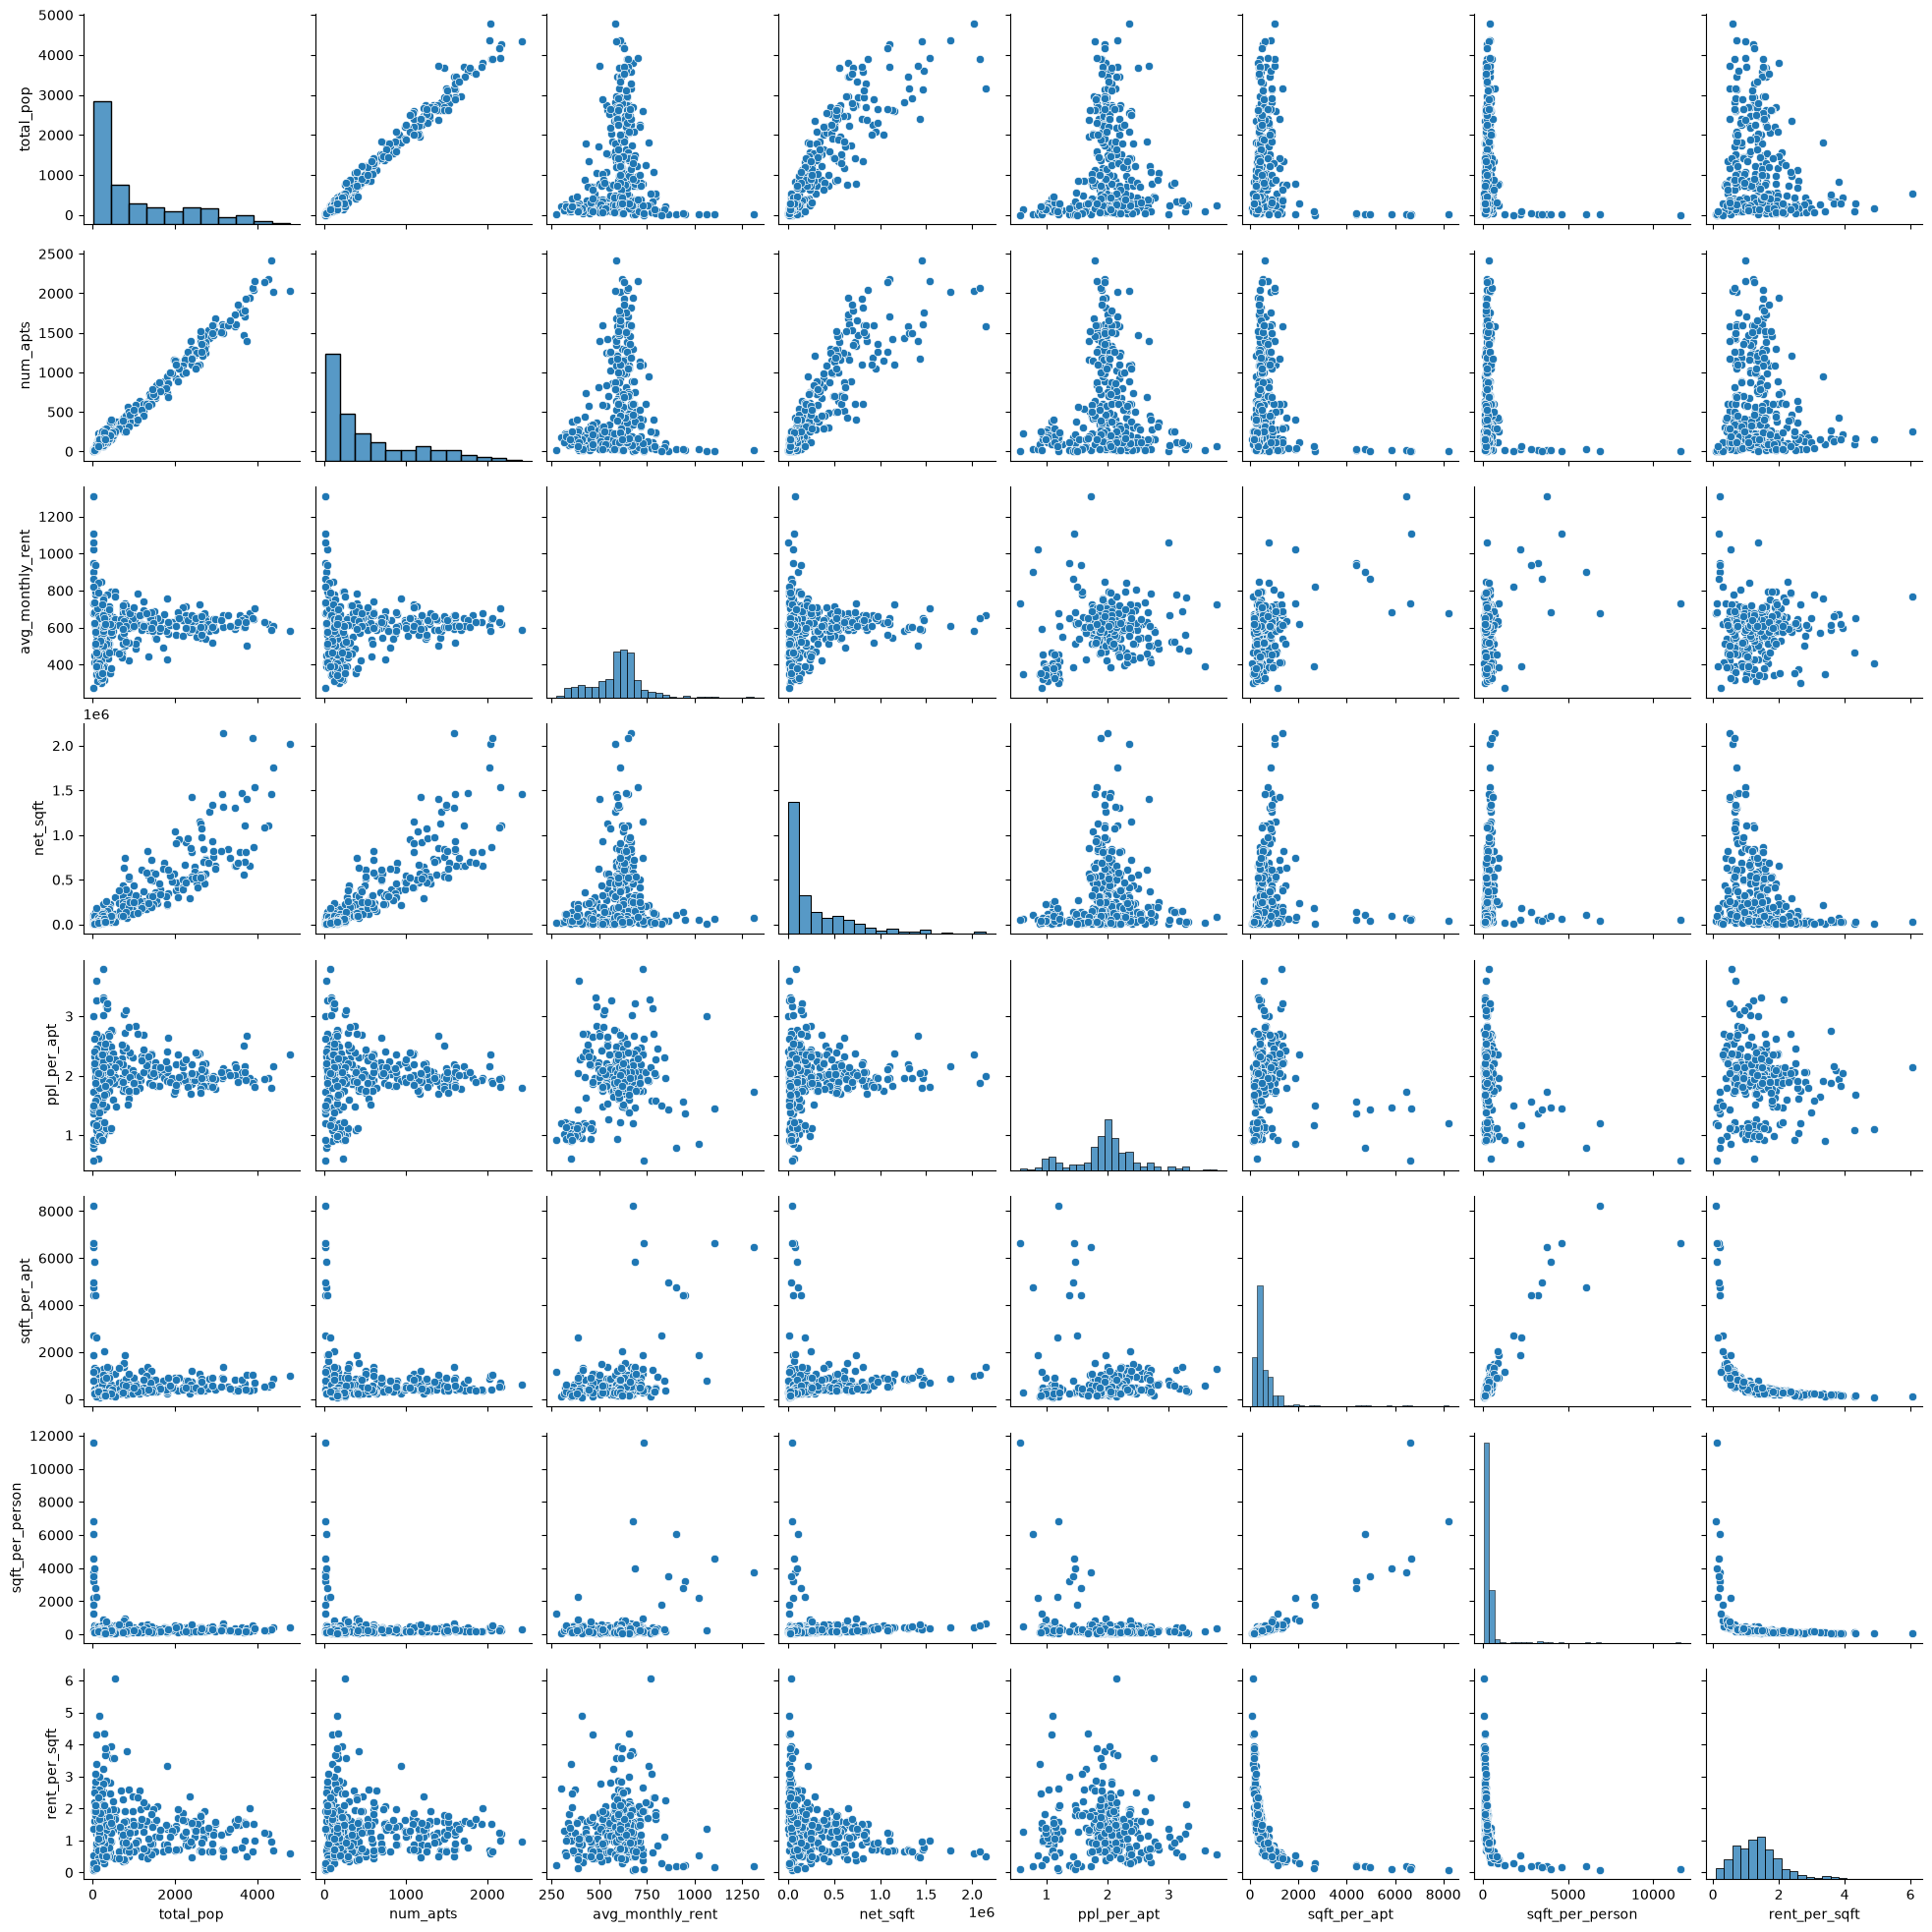

In [12]:
# make pairplots
g = sns.pairplot(nycha_df)

**Task 2.4: Take a moment to analyze the plots above; what conclusions can you draw? Write two conclusions about the histograms and two about the scatterplots**

> - 2.4 histogram conclusion #1: total_pop, num_apts, and net_sqft are right-skewed: most developments are relatively small, while a smaller number are much larger.
> - 2.4 histogram conclusion #2: sqft_per_apt and especially sqft_per_person contain extreme high values, which appear to be outliers. In contrast, avg_monthly_rent is more concentrated around the middle of its range.
> - 2.4 scatterplot conclusion #1: total_pop and num_apts appear to have a strong positive relationship—developments with more apartments generally have more residents.
> - 2.4 scatterplot conclusion #2: net_sqft also appears positively related to both total population and number of apartments, although some points are much larger than the rest.

Perhaps one of your conclusions was that some pairs of variables are correlated?

**Task 2.5: calculate the [Pearson correlation coefficients](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient) using pandas' built-in method and check if your intuition was right.**

In [13]:
# compute correlation coefficients
nycha_df.corr(numeric_only=True)

,total_pop,num_apts,avg_monthly_rent,net_sqft,ppl_per_apt,sqft_per_apt,sqft_per_person,rent_per_sqft
total_pop,1.000000,0.989474,0.145560,0.877873,0.164249,-0.102344,-0.133877,-0.143403
num_apts,0.989474,1.000000,0.118897,0.873774,0.075851,-0.114732,-0.131968,-0.132042
avg_monthly_rent,0.145560,0.118897,1.000000,0.131484,0.293830,0.411128,0.292454,0.019089
net_sqft,0.877873,0.873774,0.131484,1.000000,0.108683,0.035339,-0.036537,-0.332644
ppl_per_apt,0.164249,0.075851,0.293830,0.108683,1.000000,-0.129105,-0.285141,-0.067063
sqft_per_apt,-0.102344,-0.114732,0.411128,0.035339,-0.129105,1.000000,0.897265,-0.474817
sqft_per_person,-0.133877,-0.131968,0.292454,-0.036537,-0.285141,0.897265,1.000000,-0.351380
rent_per_sqft,-0.143403,-0.132042,0.019089,-0.332644,-0.067063,-0.474817,-0.351380,1.000000


## Square feet per apartment -- constant models

We now turn our attention to a specific question: **how much space do NYCHA residents have in their apartments?**

**Task 3.1: start by looking again a at the probability distribution of the `"sqft_per_person"` variable by plotting a histogram using seaborn's [`displot()` function](https://seaborn.pydata.org/generated/seaborn.displot.html): Store the result in a variable named `hist`.**

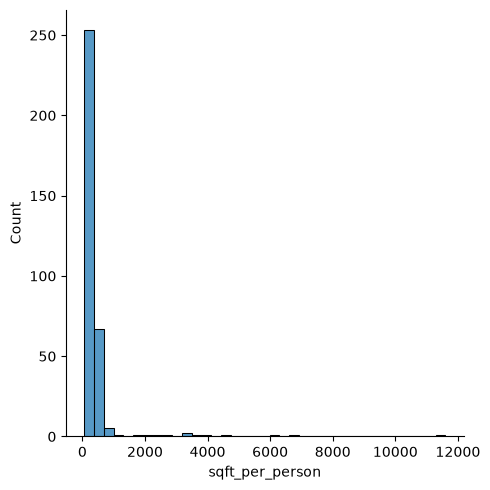

In [14]:
# plot histogram of sqft_per_person
hist = sns.displot(nycha_df, x="sqft_per_person")

Those very large numbers don't seem quite right...Let's remember that we computed `"sqft_per_person"` as the ratio between each location's total available area and its number of residents. So it could be that either of those, or both, was inaccurately reported in the dataset. 

**Task 3.2: What are some hypotheses that might explain those inaccuracies? Please write (at least) two:**

> - 3.2 #1: Some developments may have an incorrectly low reported population—for example, a missing digit—causing the area-per-person calculation to become unrealistically large.
> - 3.2 #2: NET DEV AREA SQ FT may include non-residential or shared space, such as grounds, offices, hallways, or community facilities, rather than only apartment living space.
> - 3.2 #3: A data-entry or unit-conversion error could have added an extra zero to the reported square footage for some developments.

**Task 3.3: Now pick one of the three hypotheses you laid out. How would you go about investigating it? Write some ideas here:**
> 3.3: To investigate whether population values are incorrect, I would identify the developments with the highest sqft_per_person values and compare their reported population and apartment counts with other NYCHA sources or public records. If a development has a normal number of apartments but an unusually small population, that would suggest its population data may be inaccurate.

### Constant models
There are techniques and strategies to deal with "[outliers](https://en.wikipedia.org/wiki/Outlier)" in your data. But from now on in this exercise, let's accept those outliers as true and focus on building models to predict `"sqft_per_person"`.

**Task 3.4: start off by building two constant models: one based in the mean and another one based on the median. Use pandas' Series objects built-in methods to compute those two summary statistics of the `"sqft_per_person"` column. Since the models are simply constant values, store them in the python variables `cm_mean` and `cm_median`. Then, print them out.**

In [15]:
# create constant models
cm_mean = nycha_df["sqft_per_person"].mean()
cm_median = nycha_df["sqft_per_person"].median()

# print predictions
print(f"  mean sqft per person: {cm_mean}")
print(f"median sqft per person: {cm_median}")

  mean sqft per person: 418.6411853627219
median sqft per person: 224.66126872982454


**Task 3.5: You should observe that the mean model predicts a number of square feet per person that's almost double than the median model. Why is that? Write some ideas.**

_Hint: consider the probability distribution you plotted above, and the definition/meaning of mean and median._
 
> 3.5: The mean is much larger than the median because the distribution is strongly right-skewed and contains several extremely large sqft_per_person values. The mean is pulled upward by those outliers, while the median is based on the middle observation and is much less affected by them.

### Model validation

Okay, so now that you've got your two models, it's time to ask: how well do each of those models predict the actual observed data? 

To answer that question, we need to define _how_ we're going to be measuring "goodness". We'll define two loss functions, the [mean absolute error (MAE)](https://learningds.org/ch/04/modeling_loss_functions.html?highlight=mean%20absolute%20error#mean-absolute-error) and the root mean squared error (RMSE), which is the square root of the [mean squared error (MSE)](https://learningds.org/ch/04/modeling_loss_functions.html?highlight=mean%20absolute%20error#mean-absolute-error).

**Task 3.6: Define two functions to compute RMSE and MAE. Make sure to complete the function docstrings using the [reST style](https://stackoverflow.com/a/24385103).**

In [16]:
# define loss functions

def mae_loss(y_pred, y_true):
    """Calculate mean absolute error.

    :param y_pred: Predicted value or values.
    :param y_true: Actual observed value or values.
    :returns: Mean absolute error.
    """
    return np.mean(np.abs(y_pred - y_true))


def rmse_loss(y_pred, y_true):
    """Calculate root mean squared error.

    :param y_pred: Predicted value or values.
    :param y_true: Actual observed value or values.
    :returns: Root mean squared error.
    """
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

**Task 3.7: So now we have two loss functions for two models, four combinations in total. Let's compute them into the variables. Then, print them out.**
- `cm_mean_mae`
- `cm_mean_rmse`
- `cm_median_mae`
- `cm_median_rmse`

In [17]:
# compute both loss functions for each model
cm_mean_mae = mae_loss(cm_mean, nycha_df["sqft_per_person"])
cm_mean_rmse = rmse_loss(cm_mean, nycha_df["sqft_per_person"])

cm_median_mae = mae_loss(cm_median, nycha_df["sqft_per_person"])
cm_median_rmse = rmse_loss(cm_median, nycha_df["sqft_per_person"])

In [18]:
# print losses
print("  mean constant model MAE:", cm_mean_mae)
print("  mean constant model RMSE:", cm_mean_rmse)

print(f"median constant model MAE: {cm_median_mae}")
print(f"median constant model RMSE: {cm_median_rmse}")

  mean constant model MAE: 321.2911377527004
  mean constant model RMSE: 919.7509017526434
median constant model MAE: 251.13515192162134
median constant model RMSE: 939.9840048275853


Okay, now you may be wondering: "why so many? I only really care about one model and one loss!"

If you were wondering that, you were right. Choosing a loss function is a problem-dependent exercise. In some situations you may want to focus on MAE, and in others in RMSE, as each loss function has different mathematical properties that will affect your final model. For example, RMSE computes the _square_ of the difference between prediction and actual, so if your dataset has points where that difference is very large, the loss will be magnified when taking the square; this does not happen with MAE, which weighs equally every unit of distance between prediction and actual.

### Minimize your loss functions

Let's explore the differences between loss functions by building many constant models and evaluating the loss functions on all of them.

**Task 3.8: Based on the histogram above, it seems reasonable to assume that any constant model $\theta$ that aims to predict `"sqft_per_person"` would be in the 0-1000 range. So let's use [numpy's linspace function](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html) to define an array `thetas` of values 0, 1, 2, ... 1000, each corresponding to a candiate constant model. Then loop through your `thetas`, computing the MAE and the RMSE for each `theta` value. Store your results as you loop, instantiate a `pandas.DataFrame` (see [constructor docs](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html)) with columns**
- `"theta"`
- `"mae"`
- `"rmse`"

**containing your model values and both loss values at each `theta`. Do all of this in a function `compute_losses(y_true)` that takes in a `pandas.Series` object with the true observations and returns your `pandas.DataFrame` object.**

In [19]:
# function to compute losses over many constant models

def compute_losses(y_true: pd.Series):
    """Compute MAE and RMSE losses over a range of theta values.

    :param y_true: Pandas Series with true data.
    :returns: Pandas DataFrame with MAE and RMSE values for each theta.
    """
    thetas = np.linspace(0, 1000, 1001)
    rows = []

    for theta in thetas:
        rows.append({
            "theta": theta,
            "mae": mae_loss(theta, y_true),
            "rmse": rmse_loss(theta, y_true),
        })

    return pd.DataFrame(rows)

**Task 3.9: Now call your function, the resulting dataframe in the `losses_df` variable, and display the first few rows.**

In [20]:
losses_df = compute_losses(nycha_df["sqft_per_person"])
losses_df.head()


,theta,mae,rmse
0,0.0,418.641185,1010.545478
1,1.0,417.641185,1010.131616
2,2.0,416.641185,1009.718574
3,3.0,415.641185,1009.306354
4,4.0,414.641185,1008.894957


**Task 3.10: Visualize the losses for each ouf our candidate constant model values, `"theta"` using seaborn's [`lineplot()` function](https://seaborn.pydata.org/generated/seaborn.lineplot.html). Call the function twice within the same cell, for MAE and for RMSE, to plot both curves together. Make sure to pass an argument to the `label` parameter so you can easily distinguish the curves in the plot.. Also, since the y-axis will retain the name of the latest call, call `plt.label()` to rename your y-axis label with the string `"loss"`. Store the first call's return value in a variable named `ax`, and pass `ax=ax` to the second call so both lines land on the same axes.**

Text(0, 0.5, 'loss')

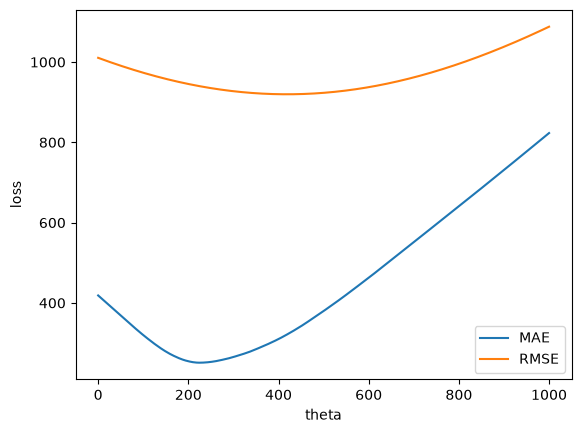

In [21]:
# plot losses at each theta

ax = sns.lineplot(
    data=losses_df,
    x="theta",
    y="mae",
    label="MAE",
)

sns.lineplot(
    data=losses_df,
    x="theta",
    y="rmse",
    label="RMSE",
    ax=ax,
)

plt.ylabel("loss")

You should observe that the MAE and the RMSE functions have their minima at very different locations. 

**Task 3.11: Let's find them. First, select the row that minimizes `"mae"`. Your output should look something like**

```
theta    123.456789
mae      234.567890
rmse     345.678901
Name: 000, dtype: float64
```
but with different values.

In [22]:
# select row that minimizes MAE
losses_df.loc[losses_df["mae"].idxmin()]

theta    224.000000
mae      251.135152
rmse     940.120690
Name: 224, dtype: float64

**Task 3.12: Now do the same but selecting the row that minimizes `"rmse"`.**

In [23]:
# select row that minimizes RMSE
losses_df.loc[losses_df["rmse"].idxmin()]

theta    419.000000
mae      321.515446
rmse     919.750972
Name: 419, dtype: float64

**Task 3.13 Inspect those values. What can you say about them? Are they familiar? Write your observations here:**

> 3.13: The value of theta that minimizes MAE is approximately the median of sqft_per_person, while the value that minimizes RMSE is approximately the mean. This makes sense because the median minimizes absolute error and the mean minimizes squared error.

### Choosing a model
You have built a set of candidate models and found the two that minimize your loss functions under consideration, MAE and RMSE. But eventually, to put a model to practical use you have to choose a single model $\theta$. 

**Task 3.14: Which one would you choose? The model that minimizes MAE or the model that minimizes RMSE? Explain your choice:**
> 3.14: I would choose the model that minimizes MAE because it gives a prediction closer to the typical NYCHA development and is less dominated by the few extremely large values. RMSE may be preferable when very large errors are especially costly, but MAE is more representative of the majority of developments in this dataset.

## Final check before submission: ensure your notebook runs in one go!
You've been programming in an interactive environment, and you may have leftover variables or functions in your namespace. Before submitting you want to ensure that your notebook executes from beginning to end in a clean kernel. 

Final task: Navigate to the "Kernel" tab above and hit "Restart Kernel and Run All Cells...". Confirm by hitting "Restart" and wait a few seconds until your code has finished running. If any cell errors out, fix your bug and repeat this process until your notebook runs completely without errors.